In [1]:
# Cell 1 — Setup

import gc
import sys
from dataclasses import asdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_project_root(start):
    """Find the repository root."""
    for candidate in (start, *start.parents):
        if (candidate / "phase1" / "src").is_dir():
            return candidate
    raise FileNotFoundError("Cannot locate the project root.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SRC_DIR = PROJECT_ROOT / "phase1" / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from dataloader.loader import get_data, load_segmented_session
from rqa import rqa as rqa_core


SESSION = "sample_1"
WINDOW_SIZES = (60, 120, 180)
M = 8
TAU_SECONDS = {"Processed": 0.16, "Raw": 0.20}
TARGET_RR = 0.02
L_MIN = 2
V_MIN = 2
RR_TOLERANCE = 5e-4
METRICS = ("DET", "Lmean", "ENTR", "Lmax", "LAM", "TT", "Vmax")

processed_awake, processed_drowsy = get_data(
    session=SESSION,
    window_sizes=WINDOW_SIZES,
    stationarity="processed",
)
raw_batches, _ = load_segmented_session(
    session=SESSION,
    window_sizes=WINDOW_SIZES,
    representation="raw",
    stationarity_only=False,
)

raw_state_data = {"Awake": {}, "Drowsy": {}}
for window_size, batch in raw_batches.items():
    for label, state in ((0, "Awake"), (1, "Drowsy")):
        selected = batch["label"] == label
        raw_state_data[state][window_size] = {
            "signal": batch["signal"][selected],
            "window_id": batch["window_id"][selected],
            "fs": batch["fs"],
        }

session_data = {
    "Processed": {
        "Awake": processed_awake,
        "Drowsy": processed_drowsy,
    },
    "Raw": raw_state_data,
}


def iter_session_windows():
    """Yield every eligible Session 1 window."""
    for representation, state_data in session_data.items():
        signal_key = (
            "processed" if representation == "Processed" else "signal"
        )
        for state, batches in state_data.items():
            for window_size, batch in batches.items():
                for index, signal in enumerate(batch[signal_key]):
                    yield {
                        "representation": representation,
                        "state": state,
                        "window_size": int(window_size),
                        "window_id": int(batch["window_id"][index]),
                        "fs": float(batch["fs"]),
                        "signal": np.asarray(signal, dtype=float),
                    }


session_windows = list(iter_session_windows())
coverage = (
    pd.DataFrame(session_windows)
    .drop(columns="signal")
    .groupby(
        ["representation", "state", "window_size"],
        observed=True,
    )
    .size()
    .rename("n_windows")
    .reset_index()
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True})

print("Session 1 fixed-RR validation")
print(f"m = {M}")
print(f"tau Processed = {TAU_SECONDS['Processed']:.2f} s")
print(f"tau Raw = {TAU_SECONDS['Raw']:.2f} s")
print(f"target RR = {TARGET_RR:.2%}")
print(f"l_min = {L_MIN}; v_min = {V_MIN}")
print("Processed eligibility = Processed stationarity")
print("Raw eligibility = SQI only; stationarity disabled")
display(coverage)


Session 1 fixed-RR validation
m = 8
tau Processed = 0.16 s
tau Raw = 0.20 s
target RR = 2.00%
l_min = 2; v_min = 2
Processed eligibility = Processed stationarity
Raw eligibility = SQI only; stationarity disabled


,representation,state,window_size,n_windows
0,Processed,Awake,60,24
1,Processed,Awake,120,11
2,Processed,Awake,180,6
3,Processed,Drowsy,60,7
4,Processed,Drowsy,120,1
5,Processed,Drowsy,180,1
6,Raw,Awake,60,24
7,Raw,Awake,120,11
8,Raw,Awake,180,6
9,Raw,Drowsy,60,10


In [2]:
# Cell 2 — Fixed-RR implementation check

representative = next(
    item
    for item in session_windows
    if item["representation"] == "Processed"
    and item["state"] == "Awake"
    and item["window_size"] == 120
)
representative_tau = int(
    round(TAU_SECONDS["Processed"] * representative["fs"])
)
representative_theiler = (M - 1) * representative_tau

representative_states = rqa_core.reconstruct_phase_space(
    representative["signal"],
    m=M,
    tau=representative_tau,
)
representative_distances = rqa_core.compute_distance_matrix(
    representative_states
)
representative_epsilon = rqa_core.compute_fixed_rr_threshold(
    representative_distances,
    theiler=representative_theiler,
    target_rr=TARGET_RR,
)
representative_recurrence = rqa_core.compute_recurrence_matrix(
    representative_distances,
    epsilon=representative_epsilon,
)
representative_recurrence = rqa_core.apply_theiler_window(
    representative_recurrence,
    theiler=representative_theiler,
)
representative_rr = rqa_core._compute_recurrence_rate(
    representative_recurrence,
    theiler=representative_theiler,
)

assert np.array_equal(
    representative_recurrence,
    representative_recurrence.T,
)
assert all(
    not np.any(np.diag(representative_recurrence, k=offset))
    for offset in range(
        -representative_theiler,
        representative_theiler + 1,
    )
)
assert representative_epsilon > 0.0
assert abs(representative_rr - TARGET_RR) < RR_TOLERANCE

implementation_check = pd.DataFrame(
    [
        {
            "representation": representative["representation"],
            "state": representative["state"],
            "window_size": representative["window_size"],
            "window_id": representative["window_id"],
            "epsilon": representative_epsilon,
            "achieved_rr": representative_rr,
            "theiler": representative_theiler,
        }
    ]
)
display(implementation_check)
print("Fixed-RR implementation check: PASS")


,representation,state,window_size,window_id,epsilon,achieved_rr,theiler
0,Processed,Awake,120,1,116.838662,0.02,56


Fixed-RR implementation check: PASS


In [3]:
# Cell 3 — New-core regression check

diagonal_lengths = rqa_core.extract_diagonal_lengths(
    representative_recurrence
)
vertical_lengths = rqa_core.extract_vertical_lengths(
    representative_recurrence
)
diagonal_metrics = rqa_core._diagonal_metrics(
    representative_recurrence,
    diagonal_lengths,
    l_min=L_MIN,
)
vertical_metrics = rqa_core._vertical_metrics(
    representative_recurrence,
    vertical_lengths,
    v_min=V_MIN,
)

manual_values = {
    "DET": diagonal_metrics[0],
    "Lmean": diagonal_metrics[1],
    "ENTR": diagonal_metrics[2],
    "Lmax": diagonal_metrics[3],
    "LAM": vertical_metrics[0],
    "TT": vertical_metrics[1],
    "Vmax": vertical_metrics[2],
    "epsilon": representative_epsilon,
    "target_rr": TARGET_RR,
    "achieved_rr": representative_rr,
    "theiler": representative_theiler,
    "n_diagonal_lines": diagonal_metrics[4],
    "n_vertical_lines": vertical_metrics[3],
}

wrapper_result = rqa_core.run_rqa(
    representative["signal"],
    m=M,
    tau=representative_tau,
    l_min=L_MIN,
    v_min=V_MIN,
    target_rr=TARGET_RR,
)
wrapper_raw = asdict(wrapper_result)
wrapper_values = {
    "DET": wrapper_raw["det"],
    "Lmean": wrapper_raw["l_mean"],
    "ENTR": wrapper_raw["entr"],
    "Lmax": wrapper_raw["l_max"],
    "LAM": wrapper_raw["lam"],
    "TT": wrapper_raw["tt"],
    "Vmax": wrapper_raw["v_max"],
    "epsilon": wrapper_raw["epsilon"],
    "target_rr": wrapper_raw["target_rr"],
    "achieved_rr": wrapper_raw["achieved_rr"],
    "theiler": wrapper_raw["theiler"],
    "n_diagonal_lines": wrapper_raw["n_diagonal_lines"],
    "n_vertical_lines": wrapper_raw["n_vertical_lines"],
}

regression_rows = []
for name, manual_value in manual_values.items():
    wrapper_value = wrapper_values[name]
    assert np.isclose(manual_value, wrapper_value)
    regression_rows.append(
        {
            "output": name,
            "functions": manual_value,
            "run_rqa": wrapper_value,
            "absolute_difference": abs(manual_value - wrapper_value),
        }
    )

regression_table = pd.DataFrame(regression_rows)
regression_max_error = regression_table["absolute_difference"].max()
display(regression_table)
print("Core regression check: PASS")

del representative_states
del representative_distances
del representative_recurrence
del diagonal_lengths
del vertical_lengths
_ = gc.collect()


,output,functions,run_rqa,absolute_difference
0,DET,0.906092,0.906092,0.0
1,Lmean,4.701877,4.701877,0.0
2,ENTR,1.910848,1.910848,0.0
3,Lmax,244.000000,244.000000,0.0
4,LAM,0.687709,0.687709,0.0
5,TT,2.451180,2.451180,0.0
6,Vmax,5.000000,5.000000,0.0
7,epsilon,116.838662,116.838662,0.0
8,target_rr,0.020000,0.020000,0.0
9,achieved_rr,0.020000,0.020000,0.0


Core regression check: PASS


In [4]:
# Cell 4 — Run all eligible Session 1 windows

session_rows = []
for position, item in enumerate(session_windows, start=1):
    tau = int(
        round(TAU_SECONDS[item["representation"]] * item["fs"])
    )
    result = rqa_core.run_rqa(
        item["signal"],
        m=M,
        tau=tau,
        l_min=L_MIN,
        v_min=V_MIN,
        target_rr=TARGET_RR,
    )
    values = asdict(result)
    session_rows.append(
        {
            "representation": item["representation"],
            "state": item["state"],
            "window_size": item["window_size"],
            "window_id": item["window_id"],
            "fs": item["fs"],
            "epsilon": values["epsilon"],
            "achieved_rr": values["achieved_rr"],
            "DET": values["det"],
            "Lmean": values["l_mean"],
            "ENTR": values["entr"],
            "Lmax": values["l_max"],
            "LAM": values["lam"],
            "TT": values["tt"],
            "Vmax": values["v_max"],
            "n_diagonal_lines": values["n_diagonal_lines"],
            "n_vertical_lines": values["n_vertical_lines"],
        }
    )
    if position % 10 == 0 or position == len(session_windows):
        print(f"Processed {position}/{len(session_windows)} windows")
        gc.collect()

session_rqa = pd.DataFrame(session_rows)
print(f"Session RQA shape: {session_rqa.shape}")
display(session_rqa.head())


Processed 10/105 windows


Processed 20/105 windows


Processed 30/105 windows


Processed 40/105 windows


Processed 50/105 windows


...

Processed 80/105 windows


Processed 90/105 windows


Processed 100/105 windows


Processed 105/105 windows
Session RQA shape: (105, 16)


,representation,state,window_size,window_id,fs,epsilon,achieved_rr,DET,Lmean,ENTR,Lmax,LAM,TT,Vmax,n_diagonal_lines,n_vertical_lines
0,Processed,Awake,60,1,50.0,117.450855,0.02,0.904122,4.727985,1.935400,132,0.644140,2.389823,5,15944,44946
1,Processed,Awake,60,2,50.0,109.782483,0.02,0.913465,4.812765,1.942604,164,0.705069,2.467688,5,15825,47645
2,Processed,Awake,60,3,50.0,114.637603,0.02,0.911378,4.610083,1.914764,149,0.713956,2.482122,5,16483,47965
3,Processed,Awake,60,4,50.0,101.614095,0.02,0.929393,5.266055,2.047586,161,0.560113,2.272143,5,14715,41107
4,Processed,Awake,60,5,50.0,108.734577,0.02,0.915672,4.775206,1.917850,168,0.638258,2.351673,5,15988,45258


In [5]:
# Cell 5 — Full QC

numeric_columns = [
    "epsilon",
    "achieved_rr",
    *METRICS,
    "n_diagonal_lines",
    "n_vertical_lines",
]
invalid_mask = ~np.isfinite(
    session_rqa[numeric_columns].to_numpy(dtype=float)
).all(axis=1)
invalid_mask |= ~session_rqa["DET"].between(0.0, 1.0)
invalid_mask |= ~session_rqa["LAM"].between(0.0, 1.0)
invalid_mask |= session_rqa["epsilon"] <= 0.0
invalid_mask |= (
    (session_rqa["n_diagonal_lines"] > 0)
    & (session_rqa["Lmax"] < session_rqa["Lmean"])
)
invalid_mask |= (
    (session_rqa["n_vertical_lines"] > 0)
    & (session_rqa["Vmax"] < session_rqa["TT"])
)

rr_error = (session_rqa["achieved_rr"] - TARGET_RR).abs()
max_rr_error = float(rr_error.max())
zero_diagonal = int((session_rqa["n_diagonal_lines"] == 0).sum())
zero_vertical = int((session_rqa["n_vertical_lines"] == 0).sum())
qc_pass = bool(
    not invalid_mask.any()
    and max_rr_error < RR_TOLERANCE
    and zero_diagonal == 0
    and zero_vertical == 0
)

qc_summary = pd.Series(
    {
        "Windows tested": len(session_rqa),
        "Invalid outputs": int(invalid_mask.sum()),
        "Max RR error": max_rr_error,
        "Zero diagonal support": zero_diagonal,
        "Zero vertical support": zero_vertical,
        "QC": "PASS" if qc_pass else "FAIL",
    },
    name="value",
)
display(qc_summary.to_frame())

if not qc_pass:
    display(session_rqa.loc[invalid_mask])
    raise AssertionError("Full Session 1 QC failed.")


,value
Windows tested,105
Invalid outputs,0
Max RR error,0.000001
Zero diagonal support,0
Zero vertical support,0
QC,PASS


In [6]:
# Cell 6 — Session-level descriptive summary

group_columns = ["representation", "state", "window_size"]
aggregations = {
    "n_windows": ("window_id", "size"),
}
for metric in METRICS:
    aggregations[f"{metric}_mean"] = (metric, "mean")
    aggregations[f"{metric}_median"] = (metric, "median")
    aggregations[f"{metric}_sd"] = (metric, "std")

descriptive_summary = (
    session_rqa.groupby(group_columns, observed=True)
    .agg(**aggregations)
    .reset_index()
    .sort_values(group_columns)
)
display(descriptive_summary)


,representation,state,window_size,n_windows,DET_mean,DET_median,DET_sd,Lmean_mean,Lmean_median,Lmean_sd,ENTR_mean,ENTR_median,ENTR_sd,Lmax_mean,Lmax_median,Lmax_sd,LAM_mean,LAM_median,LAM_sd,TT_mean,TT_median,TT_sd,Vmax_mean,Vmax_median,Vmax_sd
0,Processed,Awake,60,24,0.918084,0.919174,0.012299,4.966876,4.972188,0.329073,1.944920,1.940495,0.073937,184.250000,174.0,39.801955,0.735153,0.725728,0.091974,2.509224,2.459658,0.220576,6.041667,5.5,1.458980
1,Processed,Awake,120,11,0.918575,0.919850,0.010609,4.985234,4.994205,0.291687,1.953709,1.953481,0.051989,234.545455,244.0,45.359373,0.759895,0.783228,0.073615,2.520243,2.569770,0.117312,7.000000,7.0,1.897367
2,Processed,Awake,180,6,0.917676,0.914929,0.010463,4.973382,4.823272,0.311559,1.957499,1.948288,0.052312,234.666667,243.0,35.797579,0.754826,0.749737,0.058492,2.500680,2.507126,0.068003,6.666667,6.5,1.632993
3,Processed,Drowsy,60,7,0.931293,0.939096,0.014919,5.256252,5.256884,0.353057,1.988414,1.985278,0.070771,209.857143,204.0,42.768480,0.802732,0.791435,0.043888,2.527758,2.448311,0.152916,7.428571,7.0,2.636737
4,Processed,Drowsy,120,1,0.935083,0.935083,NaN,5.367463,5.367463,NaN,2.000068,2.000068,NaN,264.000000,264.0,NaN,0.817028,0.817028,NaN,2.503560,2.503560,NaN,11.000000,11.0,NaN
5,Processed,Drowsy,180,1,0.936743,0.936743,NaN,5.356364,5.356364,NaN,1.997947,1.997947,NaN,264.000000,264.0,NaN,0.807938,0.807938,NaN,2.478091,2.478091,NaN,11.000000,11.0,NaN
6,Raw,Awake,60,24,0.952835,0.949780,0.016289,5.431057,4.999859,0.935633,2.100599,2.049253,0.130757,205.458333,190.5,50.915940,0.975446,0.975214,0.011095,5.105385,4.799231,0.971253,18.875000,12.5,15.962762
7,Raw,Awake,120,11,0.956167,0.948174,0.015222,5.488960,5.135506,0.749784,2.121823,2.065498,0.109771,266.818182,240.0,59.854521,0.979468,0.976994,0.008898,5.386829,5.185907,0.888116,35.272727,22.0,26.608611
8,Raw,Awake,180,6,0.957421,0.956498,0.016227,5.514059,5.302984,0.879399,2.130215,2.110841,0.128318,288.000000,293.5,57.948253,0.981262,0.981561,0.008589,5.586561,5.578976,0.878337,32.333333,21.5,23.491843
9,Raw,Drowsy,60,10,0.971449,0.969861,0.009148,7.351509,6.764167,1.999075,2.343232,2.289463,0.211542,245.500000,241.5,54.772763,0.986043,0.985218,0.004377,6.335171,5.521265,2.016957,52.300000,23.0,61.573894


In [7]:
# Cell 7 — Awake versus Drowsy descriptive differences

state_means = (
    session_rqa.groupby(
        ["representation", "window_size", "state"],
        observed=True,
    )[list(METRICS)]
    .mean()
    .reset_index()
)

delta_rows = []
for (representation, window_size), group in state_means.groupby(
    ["representation", "window_size"],
    observed=True,
):
    indexed = group.set_index("state")
    if not {"Awake", "Drowsy"}.issubset(indexed.index):
        continue
    row = {
        "representation": representation,
        "window_size": window_size,
    }
    for metric in METRICS:
        row[f"delta_{metric}"] = (
            indexed.loc["Drowsy", metric]
            - indexed.loc["Awake", metric]
        )
    delta_rows.append(row)

state_delta_table = pd.DataFrame(delta_rows).sort_values(
    ["representation", "window_size"]
)
display(state_delta_table)
print("Descriptive differences only; no inferential test was run.")


,representation,window_size,delta_DET,delta_Lmean,delta_ENTR,delta_Lmax,delta_LAM,delta_TT,delta_Vmax
0,Processed,60,0.013209,0.289376,0.043494,25.607143,0.067579,0.018534,1.386905
1,Processed,120,0.016508,0.382229,0.046358,29.454545,0.057133,-0.016683,4.000000
2,Processed,180,0.019067,0.382981,0.040448,29.333333,0.053111,-0.022589,4.333333
3,Raw,60,0.018615,1.920452,0.242634,40.041667,0.010597,1.229786,33.425000
4,Raw,120,0.021304,2.493398,0.301826,117.515152,0.009936,2.034767,225.393939
5,Raw,180,0.025973,3.281069,0.374917,149.000000,0.011990,1.629791,27.666667


Descriptive differences only; no inferential test was run.


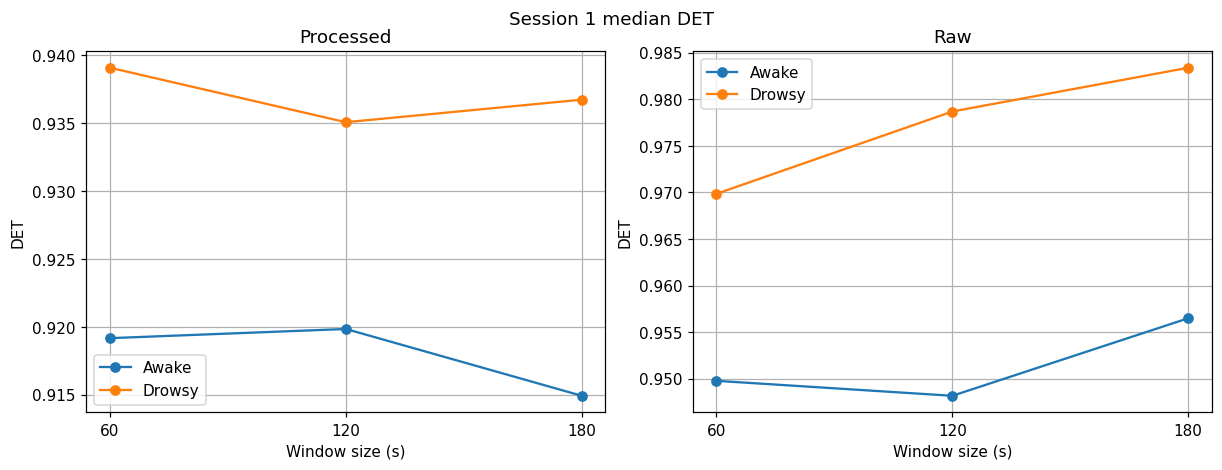

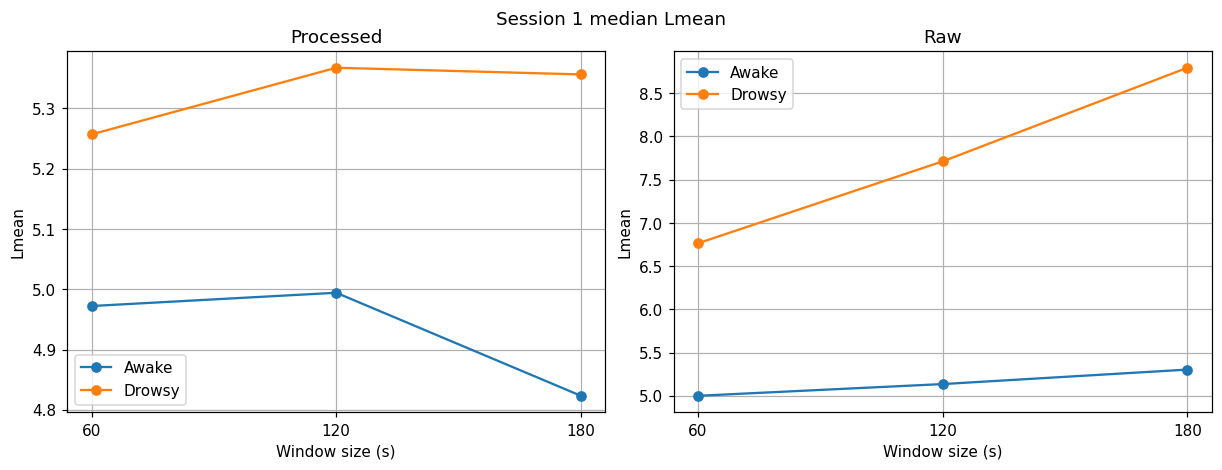

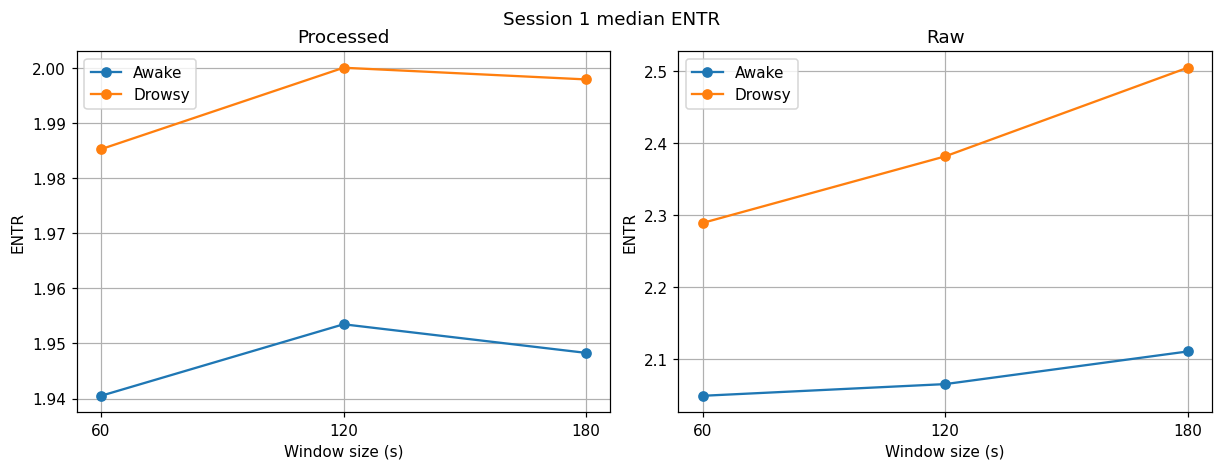

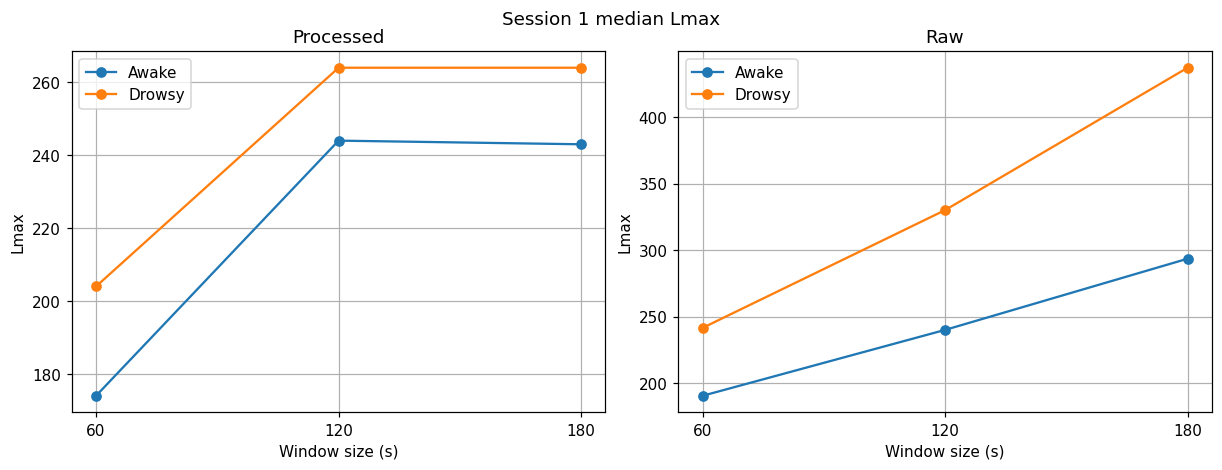

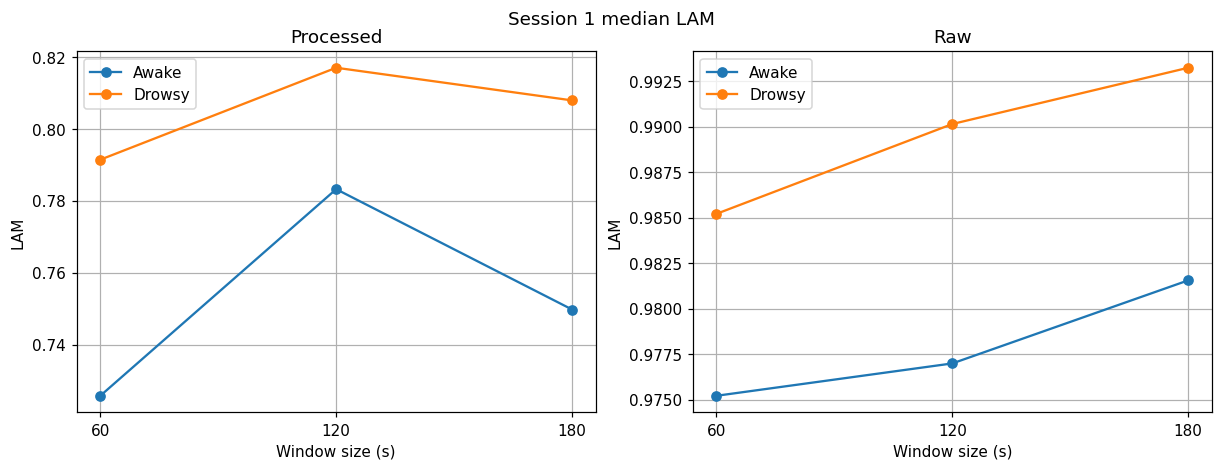

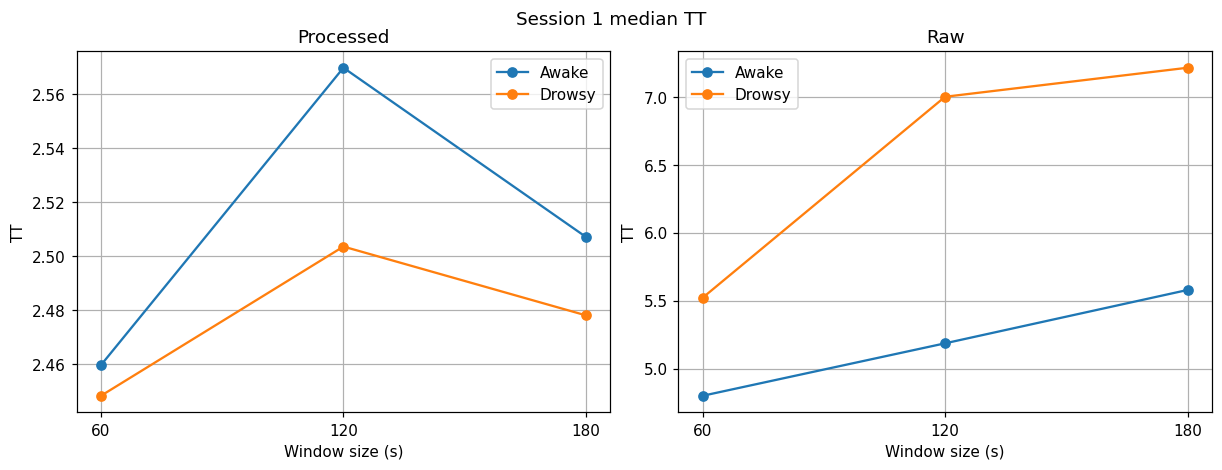

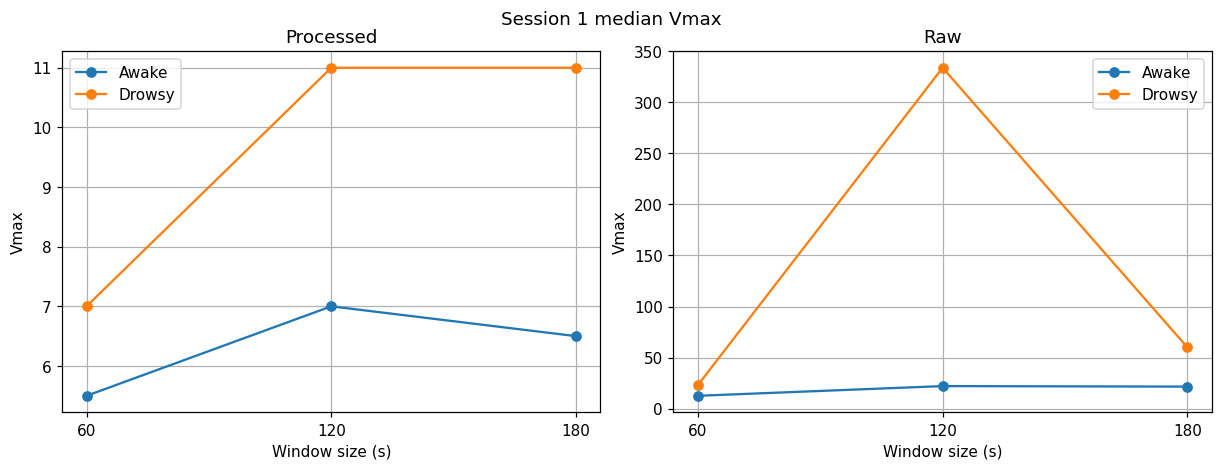

Session 1 plots are exploratory, not RQ2 inference.


In [8]:
# Cell 8 — Visualization across representation and window size

plot_summary = (
    session_rqa.groupby(
        ["representation", "state", "window_size"],
        observed=True,
    )[list(METRICS)]
    .median()
    .reset_index()
)

colors = {"Awake": "tab:blue", "Drowsy": "tab:orange"}
for metric in METRICS:
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(11, 4),
        sharex=True,
        constrained_layout=True,
    )
    for axis, representation in zip(axes, ("Processed", "Raw")):
        panel = plot_summary.loc[
            plot_summary["representation"] == representation
        ]
        for state in ("Awake", "Drowsy"):
            values = panel.loc[panel["state"] == state]
            axis.plot(
                values["window_size"],
                values[metric],
                marker="o",
                color=colors[state],
                label=state,
            )
        axis.set_title(representation)
        axis.set_xlabel("Window size (s)")
        axis.set_ylabel(metric)
        axis.set_xticks(WINDOW_SIZES)
        axis.legend()
    fig.suptitle(f"Session 1 median {metric}", y=1.03)
    plt.show()

print("Session 1 plots are exploratory, not RQ2 inference.")


# Tổng hợp validation và descriptive RQA — Session 1

## 1. Protocol và coverage

- Fixed parameters: `m = 8`, `target_rr = 0.02`, `l_min = 2`,
  `v_min = 2`.
- Delay: Processed `0.16 s`; Raw `0.20 s`.
- Theiler window: `W = (m - 1) * tau_samples`.
- Processed dùng Processed stationarity; Raw dùng SQI-only và không lọc
  stationarity.
- Tổng cộng `105` windows: `50` Processed và
  `55` Raw.

| Representation | State | Window size (s) | N |
|---|---|---:|---:|
| Processed | Awake | 60 | 24 |
| Processed | Awake | 120 | 11 |
| Processed | Awake | 180 | 6 |
| Processed | Drowsy | 60 | 7 |
| Processed | Drowsy | 120 | 1 |
| Processed | Drowsy | 180 | 1 |
| Raw | Awake | 60 | 24 |
| Raw | Awake | 120 | 11 |
| Raw | Awake | 180 | 6 |
| Raw | Drowsy | 60 | 10 |
| Raw | Drowsy | 120 | 3 |
| Raw | Drowsy | 180 | 1 |

## 2. Fixed-RR implementation và core regression

Representative window: Processed–Awake,
`120 s`, window ID `1`.

| Epsilon | Achieved RR | Theiler | Target RR |
|---:|---:|---:|---:|
| 116.838662 | 0.020000025 | 56 | 0.020000 |

- RP symmetry: `PASS`.
- LOI và toàn bộ Theiler corridor bằng zero: `PASS`.
- Fixed-RR tolerance: `PASS`.
- Sai khác lớn nhất giữa gọi từng function và `run_rqa()`:
  `0.000e+00`.
- Core regression check: `PASS`.

## 3. Full Session 1 QC

| Windows tested | Invalid outputs | Max RR error | Zero diagonal support | Zero vertical support | QC |
|---:|---:|---:|---:|---:|---|
| 105 | 0 | 1.370e-06 | 0 | 0 | PASS |

Achieved RR bám target `2%` trên toàn bộ windows. Không có output không hữu
hạn, metric ngoài bounds, hoặc quan hệ line-length pathological theo các QC
đã định nghĩa.

## 4. Median RQA theo representation × state × window size

Cell 6 cung cấp đầy đủ mean, median, SD và số windows. Bảng dưới đây giữ
median để tổng hợp ngắn gọn.

| Representation | State | Window (s) | N | DET | Lmean | ENTR | Lmax | LAM | TT | Vmax |
|---|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| Processed | Awake | 60 | 24 | 0.919174 | 4.972188 | 1.940495 | 174.000000 | 0.725728 | 2.459658 | 5.500000 |
| Processed | Awake | 120 | 11 | 0.919850 | 4.994205 | 1.953481 | 244.000000 | 0.783228 | 2.569770 | 7.000000 |
| Processed | Awake | 180 | 6 | 0.914929 | 4.823272 | 1.948288 | 243.000000 | 0.749737 | 2.507126 | 6.500000 |
| Processed | Drowsy | 60 | 7 | 0.939096 | 5.256884 | 1.985278 | 204.000000 | 0.791435 | 2.448311 | 7.000000 |
| Processed | Drowsy | 120 | 1 | 0.935083 | 5.367463 | 2.000068 | 264.000000 | 0.817028 | 2.503560 | 11.000000 |
| Processed | Drowsy | 180 | 1 | 0.936743 | 5.356364 | 1.997947 | 264.000000 | 0.807938 | 2.478091 | 11.000000 |
| Raw | Awake | 60 | 24 | 0.949780 | 4.999859 | 2.049253 | 190.500000 | 0.975214 | 4.799231 | 12.500000 |
| Raw | Awake | 120 | 11 | 0.948174 | 5.135506 | 2.065498 | 240.000000 | 0.976994 | 5.185907 | 22.000000 |
| Raw | Awake | 180 | 6 | 0.956498 | 5.302984 | 2.110841 | 293.500000 | 0.981561 | 5.578976 | 21.500000 |
| Raw | Drowsy | 60 | 10 | 0.969861 | 6.764167 | 2.289463 | 241.500000 | 0.985218 | 5.521265 | 23.000000 |
| Raw | Drowsy | 120 | 3 | 0.978695 | 7.711925 | 2.381970 | 330.000000 | 0.990157 | 7.002478 | 334.000000 |
| Raw | Drowsy | 180 | 1 | 0.983394 | 8.795128 | 2.505133 | 437.000000 | 0.993251 | 7.216352 | 60.000000 |

## 5. Awake–Drowsy descriptive differences

Các giá trị là `Drowsy mean - Awake mean`; không có inferential test.

| Representation | Window (s) | ΔDET | ΔLmean | ΔENTR | ΔLmax | ΔLAM | ΔTT | ΔVmax |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| Processed | 60 | 0.013209 | 0.289376 | 0.043494 | 25.607143 | 0.067579 | 0.018534 | 1.386905 |
| Processed | 120 | 0.016508 | 0.382229 | 0.046358 | 29.454545 | 0.057133 | -0.016683 | 4.000000 |
| Processed | 180 | 0.019067 | 0.382981 | 0.040448 | 29.333333 | 0.053111 | -0.022589 | 4.333333 |
| Raw | 60 | 0.018615 | 1.920452 | 0.242634 | 40.041667 | 0.010597 | 1.229786 | 33.425000 |
| Raw | 120 | 0.021304 | 2.493398 | 0.301826 | 117.515152 | 0.009936 | 2.034767 | 225.393939 |
| Raw | 180 | 0.025973 | 3.281069 | 0.374917 | 149.000000 | 0.011990 | 1.629791 | 27.666667 |

Directional consistency qua ba window sizes:

| Metric | Processed | Raw |
|---|---|---|
| DET | Positive at 60/120/180 s | Positive at 60/120/180 s |
| Lmean | Positive at 60/120/180 s | Positive at 60/120/180 s |
| ENTR | Positive at 60/120/180 s | Positive at 60/120/180 s |
| Lmax | Positive at 60/120/180 s | Positive at 60/120/180 s |
| LAM | Positive at 60/120/180 s | Positive at 60/120/180 s |
| TT | Mixed across window sizes | Positive at 60/120/180 s |
| Vmax | Positive at 60/120/180 s | Positive at 60/120/180 s |

Các nhóm Drowsy 120 s và 180 s có số windows nhỏ, vì vậy các differences chỉ
là mô tả Session 1. Chúng không được dùng để chọn metric hoặc kết luận RQ2.

## 6. Pre-full-run status

- Fixed-RR implementation: `PASS`.
- Manual-functions versus wrapper regression: `PASS`.
- Achieved RR trên mọi window: `PASS`.
- Diagonal và vertical line support: `PASS`.
- Numerical/pathological metric QC: `PASS`.
- Bảy figures ở Cell 8 là exploratory plots theo representation, state và
  window size; không phải statistical evidence.

Các điều kiện kỹ thuật của Session 1 để chuyển sang full-dataset run đều đạt.
Kết quả Awake–Drowsy vẫn chỉ là pre-full-run plausibility check.